In [ ]:
# Logic Details :-
# Install all the Libraries and Dependencies
# Setting Random Seeds for Reproducibility
# Run the EfficientNet Base Model
# Run the EfficientNet Base Model after added CBAM attention
# Print the Accuracy and Loss curve
# Print the t-SNE scatter plot

# Install all the Libraries and Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
!pip install torchinfo
import torch
from torchinfo import summary
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random
%matplotlib inline
plt.style.use('seaborn-v0_8')
#Resnet50, MobilenetV2, densenet121

# Setting Random Seeds for Reproducibility

In [2]:
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Run the EfficientNet Base Model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Classes: ['Normal', 'OSCC']
Number of Classes: 2
Train: 4946 | Val: 120 | Test: 126


100%|██████████| 20.5M/20.5M [00:00<00:00, 182MB/s]


Using device: cuda


Training:   0%|          | 0/619 [00:00<?, ?it/s]

...

Training:   0%|          | 0/619 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch [100/100]
Train: Loss=0.0426, Acc=0.9836, Prec=0.9836, Rec=0.9836, F1=0.9836
Val:   Loss=0.3978, Acc=0.8750, Prec=0.8197, Rec=0.8564, F1=0.8351

=== 🔍 Testing Best Model ===


Testing:   0%|          | 0/16 [00:00<?, ?it/s]


Test Results:
Loss=0.3846, Acc=0.8810, Prec=0.8469, Rec=0.8233, F1=0.8340


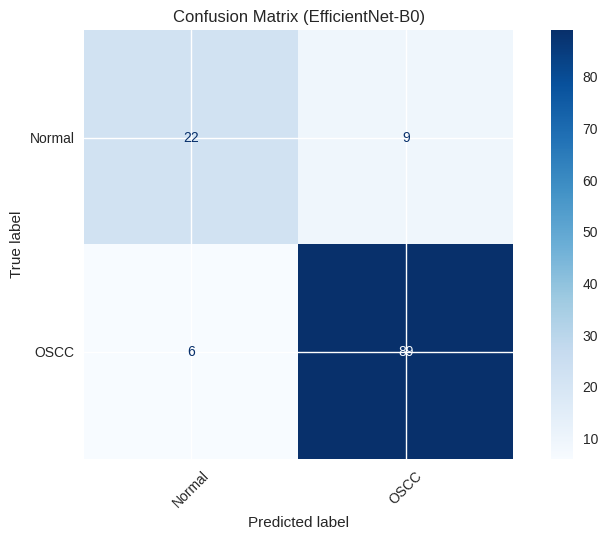

In [3]:
# =============================
# 📁 DATASET SETUP
# =============================
data_dir = "/kaggle/input/oral-squamous-cell-carcinoma-classification/Oral Squamous Cell Carcinoma (OSCC)"

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

batch_size = 8

# =============================
# 📦 TRANSFORMS
# =============================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=25, translate=(0.25, 0.25), scale=(0.75, 1.25)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# =============================
# 📊 LOAD DATASETS
# =============================
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Number of Classes: {len(class_names)}")

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# =============================
# 🧠 MODEL SETUP (EfficientNet-B0)
# =============================
# You can use 'efficientnet_b0' to 'efficientnet_b7' based on GPU memory
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Replace the classifier head
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

# =============================
# ⚙️ TRAINING SETUP
# =============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# =============================
# 📈 METRICS FUNCTION
# =============================
def compute_metrics(y_true, y_pred, average='macro'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return acc, prec, rec, f1

# =============================
# 🏋️ TRAIN ONE EPOCH
# =============================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, all_preds, all_labels = 0.0, [], []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_labels, all_preds)
    return epoch_loss, acc, prec, rec, f1

# =============================
# 🔍 VALIDATE ONE EPOCH
# =============================
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_labels, all_preds)
    return epoch_loss, acc, prec, rec, f1

# =============================
# 🧪 TEST MODEL
# =============================
def test_model(model, loader, criterion, device, class_names):
    model.eval()
    all_preds, all_labels, running_loss = [], [], 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_labels, all_preds)

    print(f"\nTest Results:\nLoss={avg_loss:.4f}, Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix (EfficientNet-B0)")
    plt.tight_layout()
    plt.show()

    return avg_loss, acc, prec, rec, f1

# =============================
# 🚀 TRAINING LOOP
# =============================
def run_training(model, train_loader, val_loader, test_loader, optimizer, criterion, device, class_names, num_epochs=100, patience=10):
    best_val_loss = float('inf')
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_prec, val_rec, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print(f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}, "
              f"Prec={train_prec:.4f}, Rec={train_rec:.4f}, F1={train_f1:.4f}")
        print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}, "
              f"Prec={val_prec:.4f}, Rec={val_rec:.4f}, F1={val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "/kaggle/working/best_efficientnet_b0.pth")
            print("✅ Best EfficientNet model saved.")

    print("\n=== 🔍 Testing Best Model ===")
    model.load_state_dict(torch.load("/kaggle/working/best_efficientnet_b0.pth"))
    test_model(model, test_loader, criterion, device, class_names)

    return train_losses, val_losses, train_accs, val_accs

# =============================
# 🏁 RUN TRAINING
# =============================
train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    class_names=class_names,
    num_epochs=100,
    patience=10
)


# Run the EfficientNet Base Model after added CBAM attention

In [ ]:
# =============================
# 📁 DATASET SETUP
# =============================
data_dir = "/kaggle/input/oral-squamous-cell-carcinoma-classification/Oral Squamous Cell Carcinoma (OSCC)"

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

batch_size = 8

# =============================
# 📦 TRANSFORMS
# =============================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=25, translate=(0.25, 0.25), scale=(0.75, 1.25)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# =============================
# 📊 LOAD DATASETS
# =============================
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Number of Classes: {len(class_names)}")

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# =============================
# 🧠 ATTENTION MODULES (CBAM)
# =============================
class SAM(nn.Module):
    def __init__(self, bias=False):
        super(SAM, self).__init__()
        self.bias = bias
        self.conv = nn.Conv2d(in_channels=2, out_channels=1, kernel_size=7, stride=1, padding=3, dilation=1, bias=self.bias)

    def forward(self, x):
        max = torch.max(x,1)[0].unsqueeze(1)
        avg = torch.mean(x,1).unsqueeze(1)
        concat = torch.cat((max,avg), dim=1)
        output = self.conv(concat)
        output = torch.sigmoid(output) * x 
        return output 

class CAM(nn.Module):
    def __init__(self, channels, r):
        super(CAM, self).__init__()
        self.channels = channels
        self.r = r
        self.linear = nn.Sequential(
            nn.Linear(in_features=self.channels, out_features=self.channels//self.r, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=self.channels//self.r, out_features=self.channels, bias=True))

    def forward(self, x):
        max = F.adaptive_max_pool2d(x, output_size=1)
        avg = F.adaptive_avg_pool2d(x, output_size=1)
        b, c, _, _ = x.size()
        linear_max = self.linear(max.view(b,c)).view(b, c, 1, 1)
        linear_avg = self.linear(avg.view(b,c)).view(b, c, 1, 1)
        output = linear_max + linear_avg
        output = torch.sigmoid(output) * x
        return output
    
class CBAM(nn.Module):
    def __init__(self, channels, r):
        super(CBAM, self).__init__()
        self.channels = channels
        self.r = r
        self.sam = SAM(bias=False)
        self.cam = CAM(channels=self.channels, r=self.r)

    def forward(self, x):
        output = self.cam(x)
        output = self.sam(output)
        return output + x

# =============================
# 🧠 MODEL SETUP (EfficientNet + CBAM)
# =============================
base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

class EfficientNet_CBAM(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNet_CBAM, self).__init__()
        self.features = base_model.features
        self.cbam = CBAM(channels=1280, r=16)  # ✅ Fixed: Added 'r' argument
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNet_CBAM(num_classes=len(class_names)).to(device)
print(f"✅ Using device: {device}")


# =============================
# ⚙️ TRAINING SETUP
# =============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# =============================
# 📈 METRICS FUNCTION
# =============================
def compute_metrics(y_true, y_pred, average='macro'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return acc, prec, rec, f1

# =============================
# 🏋️ TRAIN ONE EPOCH
# =============================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, all_preds, all_labels = 0.0, [], []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_labels, all_preds)
    return epoch_loss, acc, prec, rec, f1

# =============================
# 🔍 VALIDATE ONE EPOCH
# =============================
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_labels, all_preds)
    return epoch_loss, acc, prec, rec, f1

# =============================
# 🧪 TEST MODEL
# =============================
def test_model(model, loader, criterion, device, class_names):
    model.eval()
    all_preds, all_labels, running_loss = [], [], 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_labels, all_preds)

    print(f"\nTest Results:\nLoss={avg_loss:.4f}, Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix (EfficientNet-B0)")
    plt.tight_layout()
    plt.show()

    return avg_loss, acc, prec, rec, f1

# =============================
# 🚀 TRAINING LOOP
# =============================
def run_training(model, train_loader, val_loader, test_loader, optimizer, criterion, device, class_names, num_epochs=100, patience=10):
    best_val_loss = float('inf')
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_prec, val_rec, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        print(f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}, "
              f"Prec={train_prec:.4f}, Rec={train_rec:.4f}, F1={train_f1:.4f}")
        print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}, "
              f"Prec={val_prec:.4f}, Rec={val_rec:.4f}, F1={val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "/kaggle/working/best_efficientnet_b0.pth")
            print("✅ Best EfficientNet model saved.")

    print("\n=== 🔍 Testing Best Model ===")
    model.load_state_dict(torch.load("/kaggle/working/best_efficientnet_b0.pth"))
    test_model(model, test_loader, criterion, device, class_names)

    return train_losses, val_losses, train_accs, val_accs

# =============================
# 🏁 RUN TRAINING
# =============================
train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    class_names=class_names,
    num_epochs=100,
    patience=10
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Classes: ['Normal', 'OSCC']
Number of Classes: 2
Train: 4946 | Val: 120 | Test: 126


100%|██████████| 20.5M/20.5M [00:00<00:00, 177MB/s]


✅ Using device: cpu


Training:   0%|          | 0/619 [00:00<?, ?it/s]

torch.save(model.state_dict(), '/kaggle/working/best_efficientnet_b0.pth')
print("✅ Saved final Lung ct model weights after testing")

# Print the Accuracy and Loss curve

In [ ]:
# Load best model and test
# model.load_state_dict(torch.load("best_mobilenetv2.pth"))
model.load_state_dict(torch.load("best_efficientnet_b0.pth"))
print("\n🔍 Testing best model...")
test_loss, test_acc, test_prec, test_rec, test_f1 = test_model(model, test_loader, criterion, device, class_names)
print(f"Test Results -> Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}, F1: {test_f1:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.grid(True); plt.title("Loss Curve"); plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.grid(True); plt.title("Accuracy Curve"); plt.show()

# Print the t-SNE scatter plot

from sklearn.manifold import TSNE
# ---- Extract features from efficientnet_b0 ----
def extract_features_efficientnet_b0(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)

            # Forward pass through the convolutional feature extractor
            x = model.features(inputs)

            # Apply global average pooling manually (same as model.avgpool in ResNet)
            x = F.adaptive_avg_pool2d(x, (1, 1))  # Output shape: (batch, channels, 1, 1)
            x = torch.flatten(x, 1)               # Flatten to (batch_size, feature_dim)
            
            features.append(x.cpu().numpy())
            labels.append(targets.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)
    return features, labels


# ---- Apply t-SNE ----
def visualize_tsne_efficientnet_b0(model, dataloader, device, class_names):
    print("\n🔍 Generating t-SNE visualization for efficientnet_b0...")
    features, labels = extract_features_efficientnet_b0(model, dataloader, device)

    # t-SNE dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
    tsne_results = tsne.fit_transform(features)

    # Plotting
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        indices = labels == i
        plt.scatter(tsne_results[indices, 0], tsne_results[indices, 1],
                    label=class_name, alpha=0.7, s=20)
    
    plt.legend()
    plt.title("t-SNE Visualization of Learned Features (MobileNetV2)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True)
    plt.show()


# ---- Run visualization on test set ----
visualize_tsne_efficientnet_b0(model, test_loader, device, class_names)
